In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [28]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [29]:
pola_tests_sim = {}
load_points = [10,20,30,35,40, 45, 50]

for RHC in [0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [323.15,333.15,343.15]:
            Ucell_test = []
            Rp_test = []
            states_test = []
            n = 0
            for I_LOAD in load_points:
                operating_inputs["Phi_c_des"] = RHC
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 60), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                states = {}
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                states_test.append(states)
                n += 1
            states_profile = {}
            for key, value in enumerate(states_test[0].keys()):
                states_profile[value] = [states[value] for states in states_test]
            pola_tests_sim["RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile}

### Plot HFR

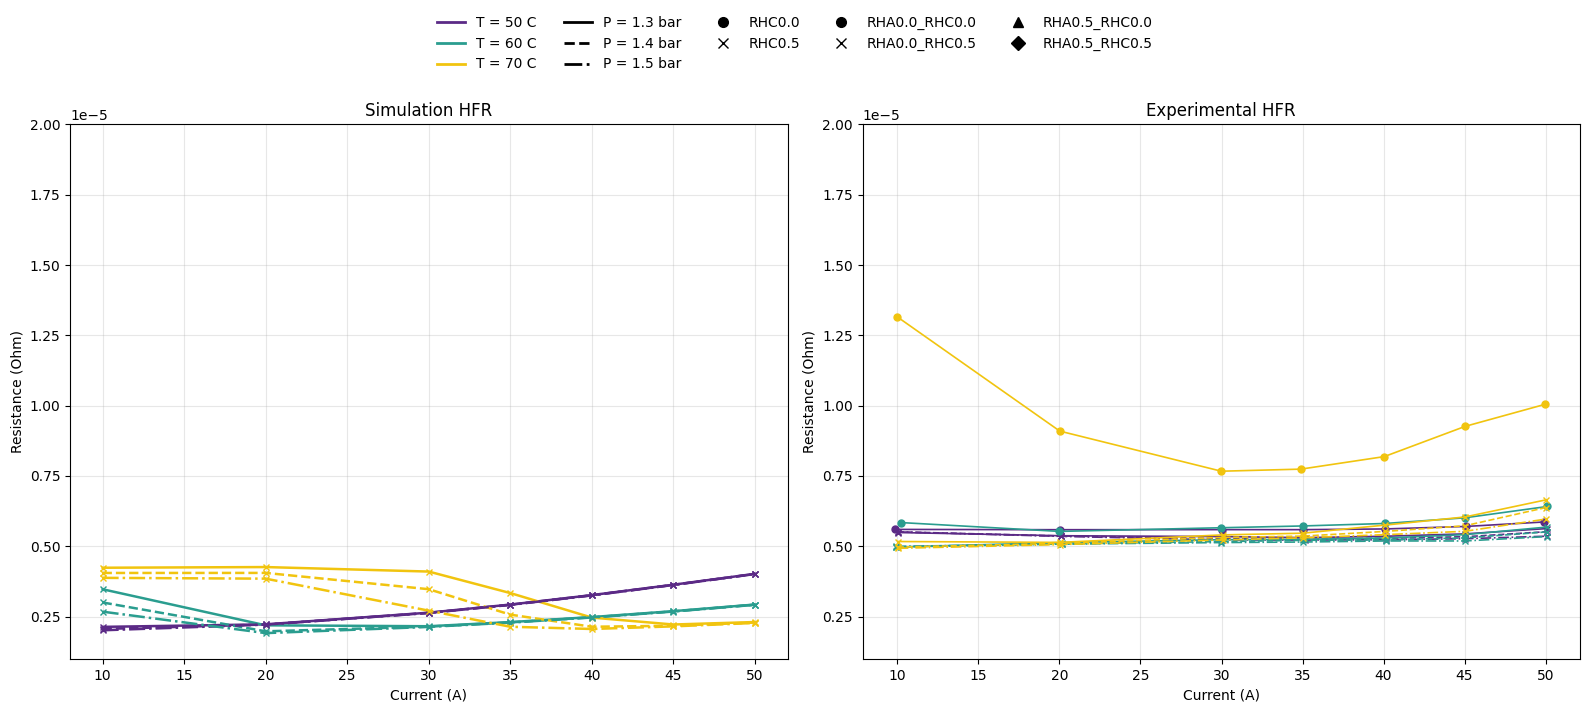

In [30]:
hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata = pd.read_excel(hfr_data_path, sheet_name=None)

fig, ax = plt.subplots(figsize=(16, 7), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    Rmem = [sum(Rmem_i) for Rmem_i in value["states"]["Rmem"]]
    plot_condition(ax[0], load_points, np.array(Rmem), key, linewidth=1.8)

ax[1].set_ylim(1e-6, 2e-5)
ax[0].set_ylim(ax[1].get_ylim())

for name, data in hfr_testdata.items():
    r_pairs = data["R"].map(literal_eval)
    r_pairs = np.array(r_pairs.tolist(), dtype=float)
    r_values = r_pairs[:, 0]
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    plot_condition(ax[1], i_values, r_values * 30e-4 / (22 * 1e3), name, linewidth=1.2, markersize=5)

legend_handles = []
for temperature, color in temp_colors.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2, label=f"T = {temperature:g} C"))
for pressure, linestyle in pressure_styles.items():
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2, linestyle=linestyle, label=f"P = {pressure:g} bar"))
for humidity, marker in humidity_markers.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="", marker=marker, markersize=7, label=humidity))

ax[0].set_title("Simulation HFR")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Resistance (Ohm)")
ax[0].grid(True, alpha=0.3)

ax[1].set_title("Experimental HFR")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Resistance (Ohm)")
ax[1].grid(True, alpha=0.3)

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

### Plot performance

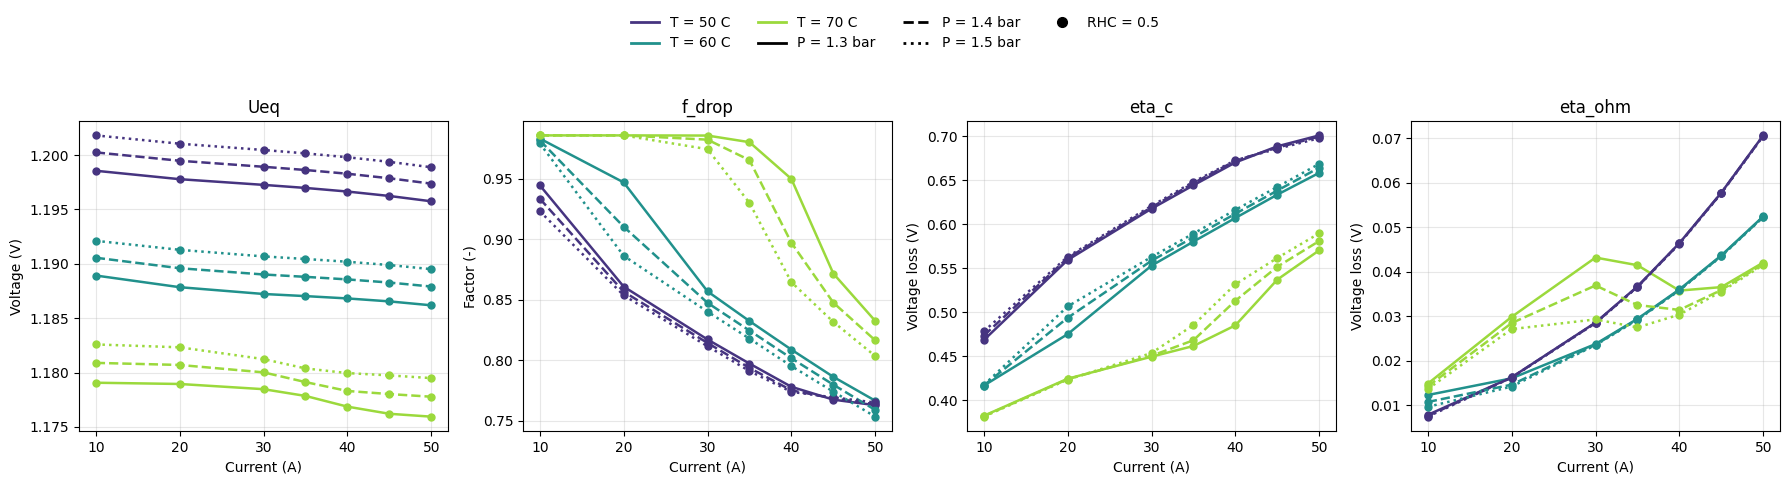

In [31]:
def parse_condition_key(key):
    match = re.fullmatch(r"RHC(?P<rhc>[-+]?\d*\.?\d+)_P(?P<pressure>[-+]?\d*\.?\d+)_T(?P<temperature>[-+]?\d*\.?\d+)", key)
    if match is None:
        raise ValueError(f"Unexpected condition key format: {key}")
    return {
        "rhc": float(match.group("rhc")),
        "pressure": float(match.group("pressure")),
        "temperature_c": float(match.group("temperature")) - 273.15,
    }


conditions = {key: parse_condition_key(key) for key in pola_tests_sim.keys()}

unique_temperatures = sorted({round(condition["temperature_c"], 1) for condition in conditions.values()})
unique_pressures = sorted({condition["pressure"] for condition in conditions.values()})
unique_humidities = sorted({condition["rhc"] for condition in conditions.values()})

temperature_palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(unique_temperatures)))
temp_colors_perf = {temperature: color for temperature, color in zip(unique_temperatures, temperature_palette)}
pressure_line_styles = ["-", "--", ":", "-."]
pressure_styles_perf = {pressure: pressure_line_styles[index % len(pressure_line_styles)] for index, pressure in enumerate(unique_pressures)}
humidity_markers_perf = {humidity: marker for humidity, marker in zip(unique_humidities, ["o", "s", "^", "D", "v", "P"])}

fig, ax = plt.subplots(figsize=(18, 4.5), nrows=1, ncols=4)

for key, value in pola_tests_sim.items():
    x_profile = value["states"]
    condition = conditions[key]
    kinetic_profile = {}
    for i in range(len(load_points)):
        x = {var_name: x_profile[var_name][i] for var_name in x_profile.keys()}
        Ueq, f_drop, eta_c = kinetics(i, x, a_slim=0.03, b_slim=0.15, a_switch=0.03,
                                                        i0_c_ref= 11,
                                                        kappa_c=0.1,
                                                        operating_inputs=operating_inputs)
        eta_ohm = (np.array(sum(x["Rmem"]), dtype=float) + parameters["Re"]) * x["i_fc"]
        kinetic_profile[i] = {"Ueq": Ueq, "f_drop": f_drop, "eta_c": eta_c, "eta_ohm": eta_ohm}

    plot_kwargs = {
        "color": temp_colors_perf[round(condition["temperature_c"], 1)],
        "linestyle": pressure_styles_perf[condition["pressure"]],
        "marker": humidity_markers_perf[condition["rhc"]],
        "linewidth": 1.8,
        "markersize": 5,
    }
    ax[0].plot(load_points, [kinetic_profile[i]["Ueq"] for i in range(len(load_points))], **plot_kwargs)
    ax[1].plot(load_points, [kinetic_profile[i]["f_drop"] for i in range(len(load_points))], **plot_kwargs)
    ax[2].plot(load_points, [kinetic_profile[i]["eta_c"] for i in range(len(load_points))], **plot_kwargs)
    ax[3].plot(load_points, [kinetic_profile[i]["eta_ohm"] for i in range(len(load_points))], **plot_kwargs)

titles = ["Ueq", "f_drop", "eta_c", "eta_ohm"]
ylabels = ["Voltage (V)", "Factor (-)", "Voltage loss (V)", "Voltage loss (V)"]

for axis, title, ylabel in zip(ax, titles, ylabels):
    axis.set_title(title)
    axis.set_xlabel("Current (A)")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)

legend_handles = []
for temperature in unique_temperatures:
    legend_handles.append(Line2D([0], [0], color=temp_colors_perf[temperature], linewidth=2, label=f"T = {temperature:g} C"))
for pressure in unique_pressures:
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2, linestyle=pressure_styles_perf[pressure], label=f"P = {pressure:g} bar"))
for humidity in unique_humidities:
    legend_handles.append(Line2D([0], [0], color="black", linestyle="", marker=humidity_markers_perf[humidity], markersize=7, label=f"RHC = {humidity:g}"))

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

In [32]:
def kinetics(i, x, a_slim, b_slim, a_switch, kappa_c, i0_c_ref, operating_inputs):

    """ 
    This function is dedicated to calibrating the kinetic parameters for the cathode catalyst layer, 
    which are used in the calculation of eta_c. It returns the intermediate values needed for calculating eta_c, 
    including Ueq, f_drop, eta_c, Rohm, and Rccl.
    """
    slim = a_slim * (operating_inputs['Pc_des'] / 1e5) + b_slim
    s_switch = a_switch * slim
    i_fc = np.array(x["i_fc"], dtype=float)
    s_ccl = np.array(x["s_ccl"], dtype=float)
    Tccl = np.array(x["Tccl"], dtype=float)
    C_O2_ccl = np.array(x["C_O2_ccl"], dtype=float)
    C_H2_acl = np.array(x["C_H2_acl"], dtype=float)
    Ueq = (E0 - 8.5e-4 * (Tccl - 298.15) + R * Tccl / (2 * F) * (np.log(R * Tccl * C_H2_acl / Pref) + 0.5 * np.log(R * Tccl * C_O2_ccl / Pref)))
    f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
    i0_c = i0_c_ref * np.exp(-Eact / R * (1 / Tccl - 1 / 353))
    eta_c = (1 / f_drop * R * Tccl / (alpha_c * F) * np.log((i_fc) / i0_c * (C_O2ref / C_O2_ccl) ** kappa_c))
    return Ueq, f_drop, eta_c

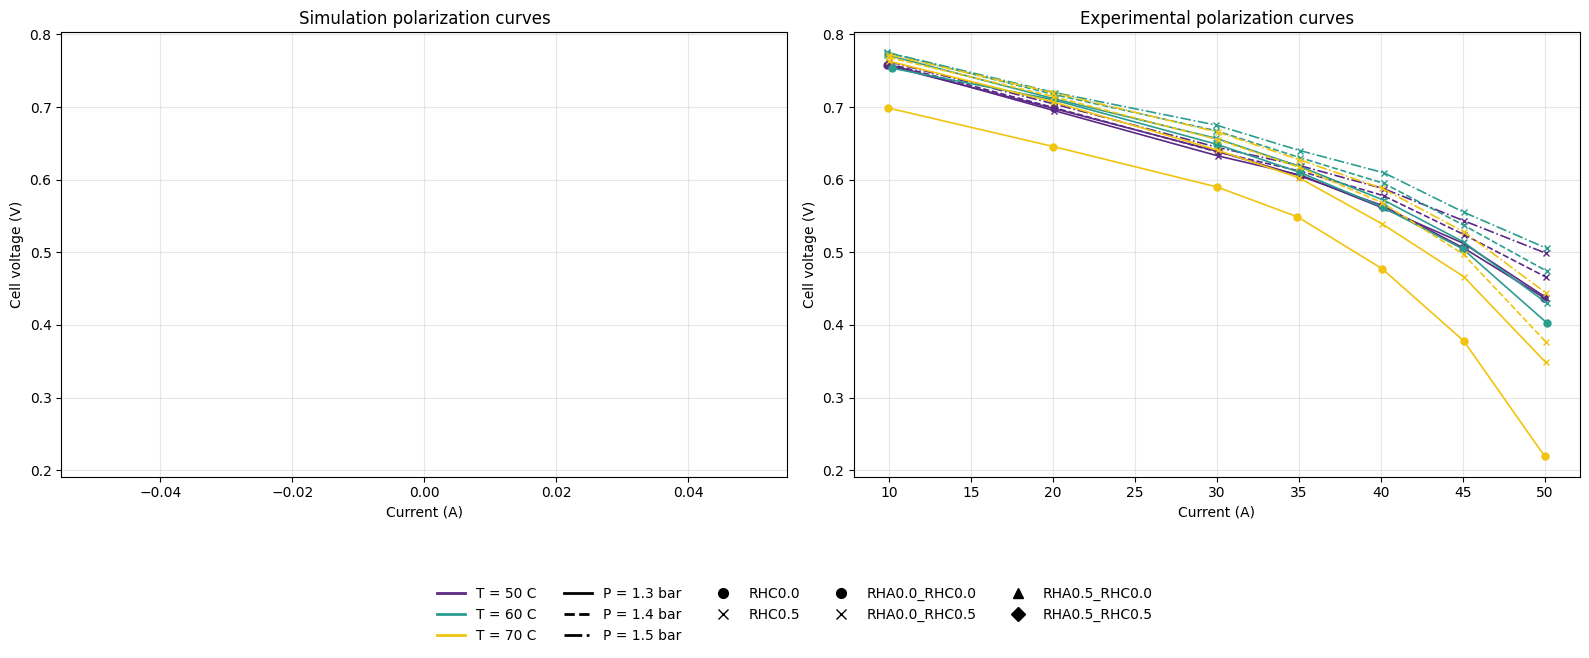

In [53]:
fig, ax = plt.subplots(figsize=(16, 6), nrows=1, ncols=2)
sim_voltage_curves = []
exp_voltage_curves = []

exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
pola_testdata = {sname: pd.read_excel(exp_pola_data, sheet_name=sname)
    for sname in exp_pola_data.sheet_names}

for key, value in pola_tests_sim.items():
    i_fc = np.array(value["states"]["i_fc"], dtype=float)
    kinetic_profile = {}
    for i in range(len(load_points)):
        x = {var_name: value["states"][var_name][i] for var_name in value["states"].keys()}
        Ueq, f_drop, eta_c = kinetics(i, x, a_slim=0.03, b_slim=0.6, a_switch=0.1,
                                                            i0_c_ref= 0.2, kappa_c=5,
                                                            operating_inputs=operating_inputs)
        eta_ohm = (np.array(sum(x["Rmem"]), dtype=float) + 1e-7) * x["i_fc"]
        kinetic_profile[i] = {"Ueq": Ueq, "f_drop": f_drop, "eta_c": eta_c, "eta_ohm": eta_ohm}

    Ueq = np.array([kinetic_profile[i]["Ueq"] for i in range(len(load_points))], dtype=float)
    eta_act = np.array([kinetic_profile[i]["eta_c"] for i in range(len(load_points))], dtype=float)
    f_drop = np.array([kinetic_profile[i]["f_drop"] for i in range(len(load_points))], dtype=float)
    eta_ohm = np.array([kinetic_profile[i]["eta_ohm"] for i in range(len(load_points))], dtype=float)

    Ucell = Ueq - eta_act - eta_ohm + R*Tfc/(2*F)* np.log(1-i_fc/1.40)
    sim_voltage_curves.append(Ucell)
    plot_condition(ax[0], load_points, Ucell, key, linewidth=1.8, markersize=5)

for name, data in pola_testdata.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    exp_voltage_curves.append(v_values)
    plot_condition(ax[1], i_values, v_values, name, linewidth=1.2, markersize=5)

legend_handles = []
for temperature, color in temp_colors.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2, label=f"T = {temperature:g} C"))
for pressure, linestyle in pressure_styles.items():
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2, linestyle=linestyle, label=f"P = {pressure:g} bar"))
for humidity, marker in humidity_markers.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="", marker=marker, markersize=7, label=humidity))

ax[0].set_title("Simulation polarization curves")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Cell voltage (V)")
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim(ax[1].get_ylim())

ax[1].set_title("Experimental polarization curves")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Cell voltage (V)")
ax[1].grid(True, alpha=0.3)

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

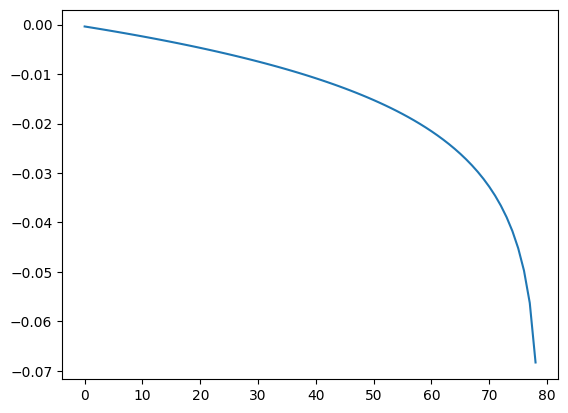

In [50]:
plt.plot(  )

### Plot water saturation

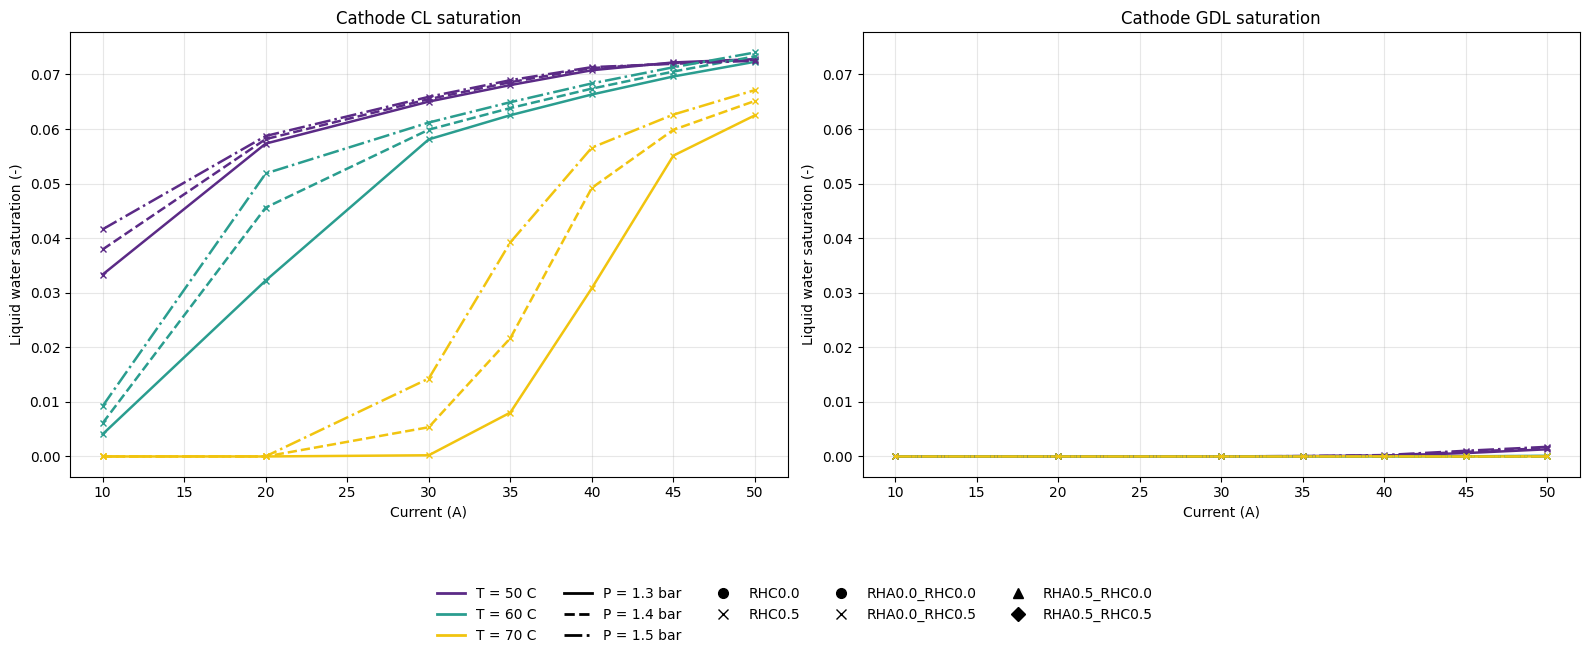

In [34]:
fig, ax = plt.subplots(figsize=(16, 6), nrows=1, ncols=2)

for key, value in pola_tests_sim.items():
    plot_condition(ax[0], load_points, np.array(value["states"]["s_ccl"], dtype=float), key, linewidth=1.8, markersize=5)
    plot_condition(ax[1], load_points, np.array(value["states"]["s_cgdl_10"], dtype=float), key, linewidth=1.8, markersize=5)

legend_handles = []
for temperature, color in temp_colors.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2, label=f"T = {temperature:g} C"))
for pressure, linestyle in pressure_styles.items():
    unit = "kPa" if pressure >= 20 else "bar"
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2, linestyle=linestyle, label=f"P = {pressure:g} {unit}"))
for humidity, marker in humidity_markers.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="", marker=marker, markersize=7, label=humidity))

ax[0].set_title("Cathode CL saturation")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Liquid water saturation (-)")
ax[0].grid(True, alpha=0.3)

ax[1].set_title("Cathode GDL saturation")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Liquid water saturation (-)")
ax[1].grid(True, alpha=0.3)
ax[1].set_ylim(ax[0].get_ylim())

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

### Plot oxygen

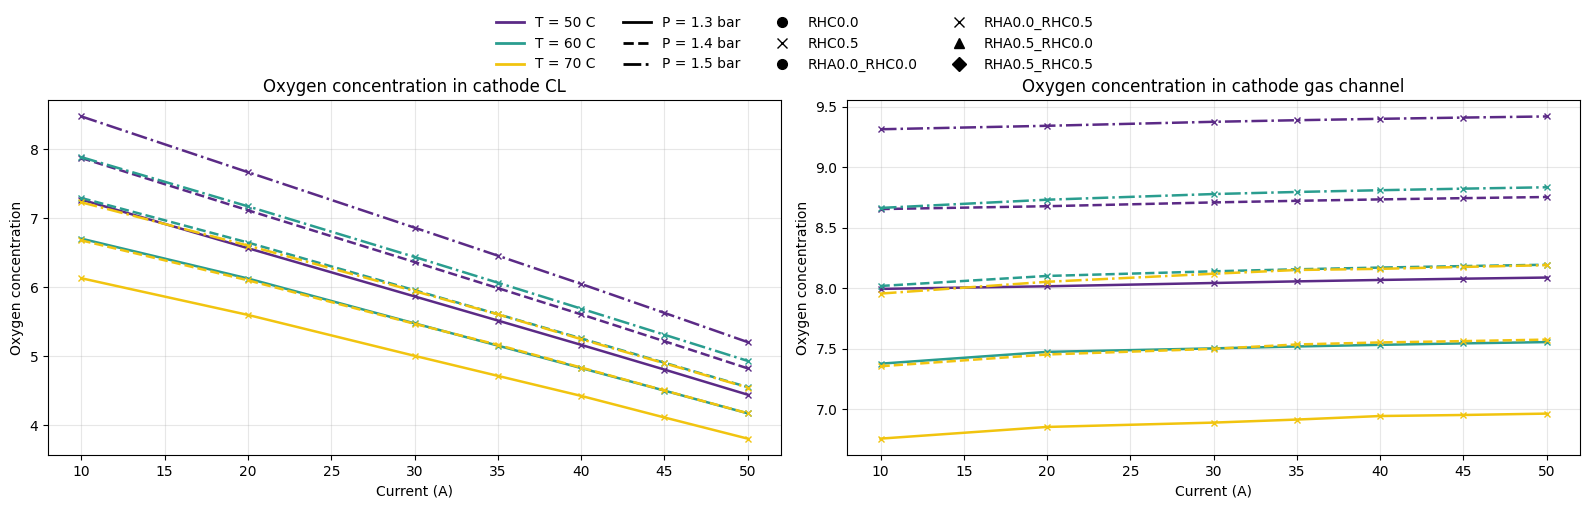

In [35]:
fig, ax = plt.subplots(figsize=(16, 5), nrows=1, ncols=2)

for key, value in pola_tests_sim.items():
    plot_condition(ax[0], load_points, np.array(value["states"]["C_O2_ccl"], dtype=float), key, linewidth=1.8, markersize=5)
    plot_condition(ax[1], load_points, np.array(value["states"]["C_O2_cgc"], dtype=float), key, linewidth=1.8, markersize=5)

legend_handles = []
for temperature, color in temp_colors.items():
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2, label=f"T = {temperature:g} C"))
for pressure, linestyle in pressure_styles.items():
    unit = "kPa" if pressure >= 20 else "bar"
    legend_handles.append(Line2D([0], [0], color="black", linewidth=2, linestyle=linestyle, label=f"P = {pressure:g} {unit}"))
for humidity, marker in humidity_markers.items():
    legend_handles.append(Line2D([0], [0], color="black", linestyle="", marker=marker, markersize=7, label=humidity))

ax[0].set_title("Oxygen concentration in cathode CL")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Oxygen concentration")
ax[0].grid(True, alpha=0.3)

ax[1].set_title("Oxygen concentration in cathode gas channel")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Oxygen concentration")
ax[1].grid(True, alpha=0.3)

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()